In [44]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv("C:/Users/appas/Downloads/Ecommerce_Delivery_Analytics_New.csv")

In [46]:
# Dropping ID columns
df = df.drop(["Order ID", "Customer ID"], axis=1)
df.head()

,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


In [47]:
# Check missing values
df.isnull().sum()

Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

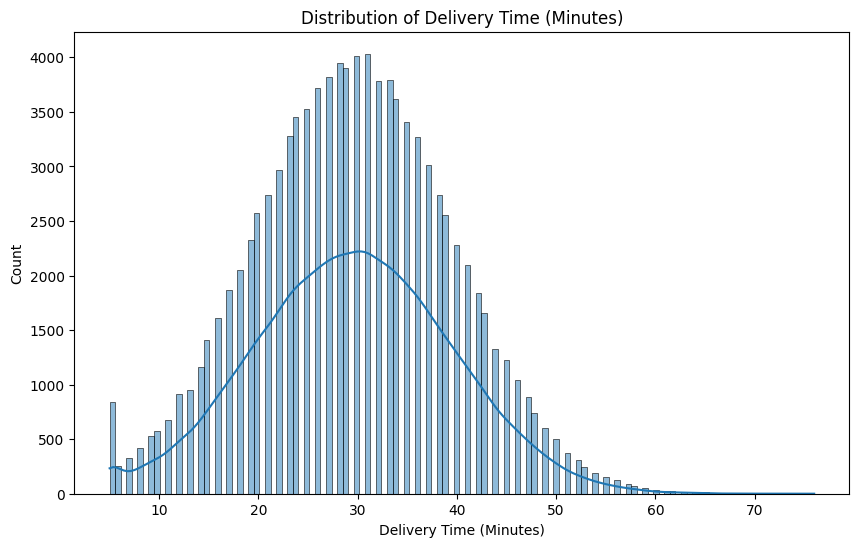

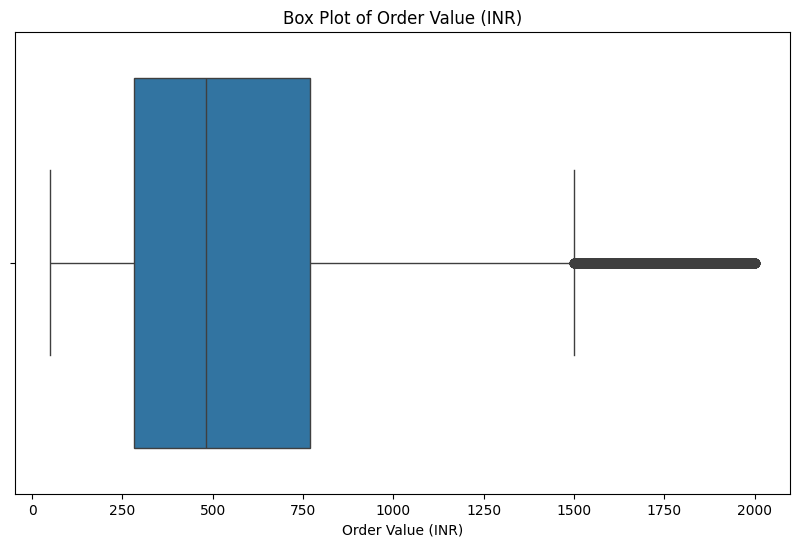

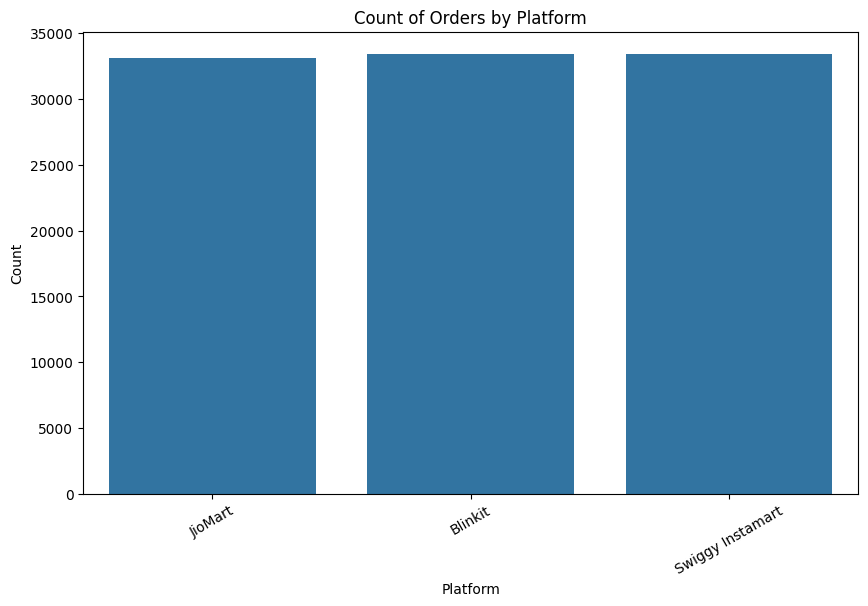

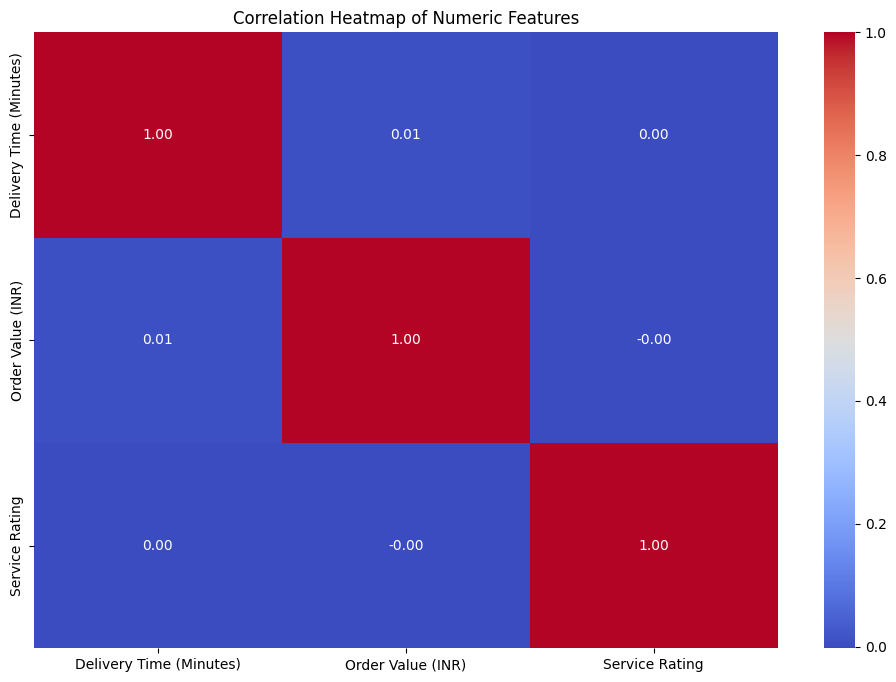

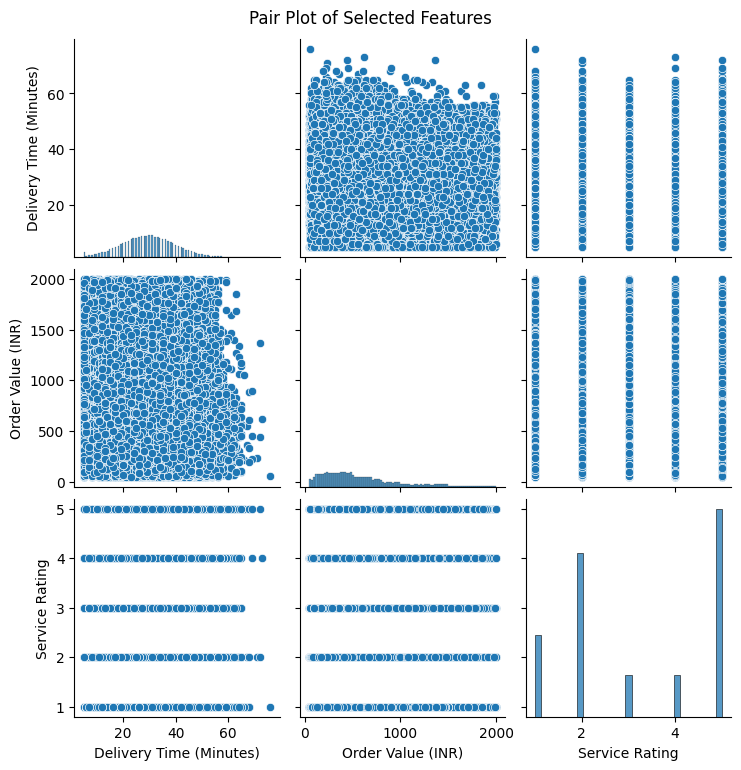

In [48]:
# 1. Histogram - Delivery Time
if "Delivery Time (Minutes)" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["Delivery Time (Minutes)"], kde=True)
    plt.title("Distribution of Delivery Time (Minutes)")
    plt.xlabel("Delivery Time (Minutes)")
    plt.ylabel("Count")
    plt.show()

# 2. Box Plot - Order Value
if "Order Value (INR)" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df["Order Value (INR)"])
    plt.title("Box Plot of Order Value (INR)")
    plt.xlabel("Order Value (INR)")
    plt.show()

# 3. Count Plot - Platform
if "Platform" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x="Platform")
    plt.title("Count of Orders by Platform")
    plt.xlabel("Platform")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

# 4. Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 2:
    plt.figure(figsize=(12, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Features")
    plt.show()

# 5. Pair Plot (Selected Features)
cols_for_pairplot = [
    "Delivery Time (Minutes)",
    "Order Value (INR)",
    "Service Rating"
]

existing_cols = [col for col in cols_for_pairplot if col in df.columns]

if len(existing_cols) >= 2:
    sns.pairplot(df[existing_cols].dropna())
    plt.suptitle("Pair Plot of Selected Features", y=1.02)
    plt.show()

In [49]:
# Encoding target variable
df["Delivery Delay"] = df["Delivery Delay"].map({"Yes": 1, "No": 0})

In [50]:
# Encode Refund Requested
df["Refund Requested"] = df["Refund Requested"].map({"Yes": 1, "No": 0})

In [51]:
# Dropping text column (optional for basic model)
df = df.drop("Customer Feedback", axis=1)

In [52]:
df = df.drop("Delivery Time (Minutes)", axis=1)

In [53]:
from sklearn.model_selection import train_test_split

y = df["Delivery Delay"]
X = df.drop("Delivery Delay", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
# Encode categorical columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000,
        solver='lbfgs',
        class_weight='balanced' 
    ))
])

pipeline_lr.fit(X_train_encoded, y_train)

y_pred_lr = pipeline_lr.predict(X_test_encoded)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.5131


In [56]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_encoded, y_train)

y_pred_dt = dt.predict(X_test_encoded)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.76075


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train)

y_pred_rf = rf.predict(X_test_encoded)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7958


In [58]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_encoded, y_train)

y_pred_knn = knn.predict(X_test_encoded)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.85025


In [59]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_encoded, y_train)

y_pred_nb = nb.predict(X_test_encoded)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.7051


In [60]:
print("\nModel Comparison")
print("----------------------------")
print("Logistic Regression :", acc_lr)
print("Decision Tree       :", acc_dt)
print("Random Forest       :", acc_rf)
print("KNN                 :", acc_knn)
print("Naive Bayes         :", acc_nb)


Model Comparison
----------------------------
Logistic Regression : 0.5131
Decision Tree       : 0.76075
Random Forest       : 0.7958
KNN                 : 0.85025
Naive Bayes         : 0.7051


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

In [62]:
metrics_lr = evaluate_model(y_test, y_pred_lr)
metrics_dt = evaluate_model(y_test, y_pred_dt)
metrics_rf = evaluate_model(y_test, y_pred_rf)
metrics_knn = evaluate_model(y_test, y_pred_knn)
metrics_nb = evaluate_model(y_test, y_pred_nb)

In [63]:
import pandas as pd

comparison = pd.DataFrame({
    "Logistic Regression": metrics_lr,
    "Decision Tree": metrics_dt,
    "Random Forest": metrics_rf,
    "KNN": metrics_knn,
    "Naive Bayes": metrics_nb
}).T

print("\nModel Comparison")
print("----------------------------")
print(comparison)


Model Comparison
----------------------------
                     Accuracy  Precision   Recall  F1 Score
Logistic Regression   0.51310   0.766347  0.51310  0.589809
Decision Tree         0.76075   0.765175  0.76075  0.762946
Random Forest         0.79580   0.766773  0.79580  0.780489
KNN                   0.85025   0.767826  0.85025  0.800969
Naive Bayes           0.70510   0.768587  0.70510  0.733456


In [64]:
import pandas as pd

# Create dictionary with your results
data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy": [0.51310, 0.76075, 0.79580, 0.85025, 0.70510],
    "Precision": [0.766347, 0.765175, 0.766773, 0.767826, 0.768587],
    "Recall": [0.51310, 0.76075, 0.79580, 0.85025, 0.70510],
    "F1 Score": [0.589809, 0.762946, 0.780489, 0.800969, 0.733456]
}

df = pd.DataFrame(data)

print(df)

                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression   0.51310   0.766347  0.51310  0.589809
1        Decision Tree   0.76075   0.765175  0.76075  0.762946
2        Random Forest   0.79580   0.766773  0.79580  0.780489
3                  KNN   0.85025   0.767826  0.85025  0.800969
4          Naive Bayes   0.70510   0.768587  0.70510  0.733456


In [66]:
# Save to Excel file
df.to_excel("Delivery_Analytics_Results.xlsx", index=False)

print("Excel file saved successfully!")

Excel file saved successfully!
